# NB-01 — EDA Series Temporales RBL (Recolección, Barrido y Limpieza)
## DataJam Bogotá 2026

**Objetivo:** Inventariar y evaluar la calidad de los ~65 archivos RBL (2017–2026) antes de decidir qué usar en Silver.

**Hipótesis general del proyecto:** Las zonas de estrato bajo presentan mayor producción de residuos no controlada (arrojo clandestino) y menor eficiencia en la cobertura de recolección.

**Secciones:**
1. Inventario automático de archivos
2. Lectura exploratoria por año (esquemas, encoding)
3. Comparación de esquemas entre años
4. Calidad de datos (nulos, duplicados, valores atípicos)
5. Serie temporal visual (2017–2026)
6. Tabla de decisiones (✅ útil / ⚠️ parcial / ❌ descartar)

In [1]:
import os
import glob
import chardet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Ruta base del proyecto
BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
BRONZE = os.path.join(BASE, 'Bronze')

print(f'Base del proyecto: {BASE}')
print(f'Bronze: {BRONZE}')
sns.set_theme(style='whitegrid', palette='muted')

Base del proyecto: /home/naciscric/Documentos/DataJamBlackStar
Bronze: /home/naciscric/Documentos/DataJamBlackStar/Bronze


## 1. Inventario Automático de Archivos

In [2]:
YEARS = list(range(2017, 2027))
inventory = []

for year in YEARS:
    year_dir = os.path.join(BRONZE, str(year))
    if not os.path.isdir(year_dir):
        continue
    files = os.listdir(year_dir)
    for f in files:
        fpath = os.path.join(year_dir, f)
        ext = os.path.splitext(f)[1].lower()
        size_kb = os.path.getsize(fpath) / 1024
        inventory.append({
            'año': year,
            'archivo': f,
            'formato': ext,
            'tamaño_kb': round(size_kb, 1),
            'ruta': fpath
        })

inv_df = pd.DataFrame(inventory)
print(f'Total archivos: {len(inv_df)}')
print(f'\nPor año:')
print(inv_df.groupby(['año', 'formato']).size().reset_index(name='n_archivos').to_string(index=False))
inv_df

Total archivos: 87

Por año:
 año formato  n_archivos
2017    .csv           1
2018    .csv          13
2019    .csv           9
2020    .csv           5
2021   .xlsx           9
2022   .xlsx          11
2023   .xlsx          10
2024   .xlsx          12
2025   .xlsx          12
2026   .xlsx           5


,año,archivo,formato,tamaño_kb,ruta
0,2017,data_set_noviembre_2017_rbl.csv,.csv,1.2,/home/naciscric/Documentos/DataJamBlackStar/Br...
1,2018,agosto-2018-rbl-residuos.csv,.csv,0.8,/home/naciscric/Documentos/DataJamBlackStar/Br...
2,2018,data-set-agosto_2018.csv,.csv,0.6,/home/naciscric/Documentos/DataJamBlackStar/Br...
3,2018,data-set-rbl-febrero-2018.csv,.csv,1.1,/home/naciscric/Documentos/DataJamBlackStar/Br...
4,2018,data-set-rbl_nuevo_esquema_aseo.csv,.csv,1.1,/home/naciscric/Documentos/DataJamBlackStar/Br...
...,...,...,...,...,...
82,2026,data-_set_abril_2026_srbl.xlsx,.xlsx,11.9,/home/naciscric/Documentos/DataJamBlackStar/Br...
83,2026,data-_set_enero_2026_srbl.xlsx,.xlsx,11.9,/home/naciscric/Documentos/DataJamBlackStar/Br...
84,2026,data-_set_feb_2026_srbl.xlsx,.xlsx,11.9,/home/naciscric/Documentos/DataJamBlackStar/Br...
85,2026,data-_set_marzo_2026_srbl.xlsx,.xlsx,10.6,/home/naciscric/Documentos/DataJamBlackStar/Br...


## 2. Lectura Exploratoria por Año — Esquemas y Encoding

In [3]:
def detectar_encoding(filepath):
    """Detecta el encoding de un archivo usando chardet."""
    with open(filepath, 'rb') as f:
        raw = f.read(50000)
    result = chardet.detect(raw)
    return result.get('encoding', 'utf-8'), result.get('confidence', 0)

def leer_csv_rbl(filepath):
    """Intenta leer un CSV RBL probando distintos separadores y encodings."""
    enc, conf = detectar_encoding(filepath)
    for sep in [';', ',', '\t']:
        for enc_try in [enc, 'utf-8', 'latin-1', 'iso-8859-1']:
            try:
                df = pd.read_csv(filepath, sep=sep, encoding=enc_try,
                                 skiprows=0, nrows=5, engine='python')
                if df.shape[1] > 2:
                    return df, enc_try, sep, conf
            except Exception:
                continue
    return None, enc, ';', conf

print('=== Exploración de CSV (2017-2020) ===\n')
csv_files = inv_df[inv_df['formato'] == '.csv'].copy()

for _, row in csv_files.iterrows():
    df, enc, sep, conf = leer_csv_rbl(row['ruta'])
    if df is not None:
        print(f"📄 {row['año']}/{row['archivo']}")
        print(f"   Encoding: {enc} (confianza: {conf:.0%}) | Separador: '{sep}'")
        print(f"   Columnas ({df.shape[1]}): {list(df.columns)[:5]}...")
        print()
    else:
        print(f"❌ No se pudo leer: {row['año']}/{row['archivo']}")

=== Exploración de CSV (2017-2020) ===

📄 2017/data_set_noviembre_2017_rbl.csv
   Encoding: ISO-8859-1 (confianza: 4%) | Separador: ';'
   Columnas (9): ['NOVIEMBRE 2017', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']...

📄 2018/agosto-2018-rbl-residuos.csv
   Encoding: ascii (confianza: 100%) | Separador: ';'
   Columnas (9): ['ASE y Concesionario', 'Residuos Recogidos Domiciliarios (toneladas/mes) ', 'Residuos de Recogidos de Barrido (toneladas/mes) ', 'Residuos de Recogidos de Corte Cesped (toneladas/mes) ', 'Residuos de Recogidos de Grandes Generadores (toneladas/mes) ']...

📄 2018/data-set-agosto_2018.csv
   Encoding: cp850 (confianza: 3%) | Separador: ';'
   Columnas (9): [' Area de Servicio Exclusivo ASE  y Concesionario ', ' Domiciliarios ', ' Barrido ', ' Corte Cesped ', 'Grandes Generadores ']...

📄 2018/data-set-rbl-febrero-2018.csv
   Encoding: ISO-8859-1 (confianza: 5%) | Separador: ';'
   Columnas (9): ['Año/Mes Formato (dd-mmm-yy)', 'Operador y Zona', 'Residuos

In [4]:
print('=== Exploración de XLSX (2021-2026) ===\n')
xlsx_files = inv_df[inv_df['formato'] == '.xlsx'].copy()

for _, row in xlsx_files.iterrows():
    try:
        xf = pd.ExcelFile(row['ruta'])
        print(f"📊 {row['año']}/{row['archivo']}")
        print(f"   Hojas: {xf.sheet_names}")
        df = pd.read_excel(row['ruta'], sheet_name=0, nrows=3)
        print(f"   Columnas ({df.shape[1]}): {list(df.columns)[:6]}...")
        print()
    except Exception as e:
        print(f"❌ Error en {row['año']}/{row['archivo']}: {e}")

=== Exploración de XLSX (2021-2026) ===



📊 2021/data-set-abril.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Ano/Mes Formato (dd-mmm-yy)', 'Area de Servicio Exclusivo y Concesionario', 'Residuos Recogidos Domiciliarios (toneladas/mes) ', 'Residuos de Recogidos de Barrido (toneladas/mes) ', 'Residuos de Recogidos de Corte Cesped (toneladas/mes) ', 'Residuos de Recogidos de Grandes Generadores (toneladas /mes) ']...



📊 2021/data-set-diciembre.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Ano/Mes Formato (dd-mmm-yy)', 'Area de Servicio Exclusivo y Concesionario', 'Residuos Recogidos Domiciliarios (toneladas/mes) ', 'Residuos de Recogidos de Barrido (toneladas/mes) ', 'Residuos de Recogidos de Corte Cesped (toneladas/mes) ', 'Residuos de Recogidos de Grandes Generadores (toneladas /mes) ']...

📊 2021/data-set-enero.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Ano/Mes Formato (dd-mmm-yy)', 'Area de Servicio Exclusivo y Concesionario', 'Residuos Recogidos Domiciliarios (toneladas/mes) ', 'Residuos de Recogidos de Barrido (toneladas/mes) ', 'Residuos de Recogidos de Corte Cesped (toneladas/mes) ', 'Residuos de Recogidos de Grandes Generadores (toneladas /mes) ']...

📊 2021/data-set-febrero.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Ano/Mes Formato (dd-mmm-yy)', 'Area de Servicio Exclusivo y Concesionario', 'Residuos Recogidos Domiciliarios (toneladas/mes) ', 'Residuos de Recogidos de Barrido (toneladas

📊 2022/data-set-mayo-2022.xlsx
   Hojas: ['Hoja1']
   Columnas (11): ['´MAYO 2022', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']...

📊 2022/data-set-noviembre-2022.xlsx
   Hojas: ['Hoja1']
   Columnas (12): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2022/data-set-octubre-2022.xlsx
   Hojas: ['Hoja1']
   Columnas (12): ['Ano/Mes Formato (dd-mmm-yy)', 'Area de Servicio Exclusivo y Concesionario', 'Residuos Recogidos Domiciliarios (toneladas/mes) ', 'Residuos de Recogidos de Barrido (toneladas/mes) ', 'Residuos de Recogidos de Corte Cesped (toneladas/mes) ', 'Residuos de Recogidos de Grandes Generadores (toneladas /mes) ']...

📊 2022/data-set-septiembre-2022.xlsx
   Hojas: ['Hoja1']
   Columnas (12): ['Ano/Mes Formato (dd-mmm-yy)', 'Area de Servicio Exc

📊 2023/data-set-enero-2023.xlsx
   Hojas: ['Hoja1']
   Columnas (13): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2023/data-set-feb-2023.xlsx
   Hojas: ['Hoja1']


   Columnas (12): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2023/data-set-julio-2023.xlsx
   Hojas: ['Hoja1']
   Columnas (11): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2023/data-set-marzo-2023.xlsx
   Hojas: ['Hoja1']
   Columnas (12): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2023/data-set-mayo-2023.xlsx
   Hojas: ['Hoja1']
   Columnas (12): ['Año

📊 2024/data-set-mayo-2024.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['´MAYO 2024', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']...

📊 2024/data-set-noviembre-2024rbl.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2024/data-set-octubre-2024rbl.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2024/data-set-septiembre-2024.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['SEPTIEMBRE 2024', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']...

📊 2025/da

   Columnas (10): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2025/data-set-diciembre-2025-srbl.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...



📊 2025/data-set-enero-2025-srbl.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos  Recogidos de Barrido (t/mes) ', 'Residuos  Recogidos de Corte Césped (t/mes) ', 'Residuos  Recogidos de Grandes Generadores (t/mes) ']...

📊 2025/data-set-febrero-2025-srbl.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2025/data-set-julio-2025-srbl-1.xlsx
   Hojas: ['Hoja1']
   Columnas (10): ['Año/Mes Formato (dd-mmm-yy)', 'ASE y Concesionario', 'Residuos Recogidos Domiciliarios (t/mes) ', 'Residuos de Recogidos de Barrido (t/mes) ', 'Residuos de Recogidos de Corte Césped (t/mes) ', 'Residuos de Recogidos de Grandes Generadores (t/mes) ']...

📊 2025/da

## 3. Comparación de Esquemas Entre Años

In [5]:
# Columnas esperadas (normalizadas) por tipo de residuo
COLUMNAS_OBJETIVO = [
    'domiciliarios', 'barrido', 'corte_cesped',
    'grandes_generadores', 'arrojo_clandestino',
    'poda_arboles', 'total'
]

def normalizar_columna(col):
    """Mapea columnas originales a nombres estandarizados."""
    col_l = str(col).lower()
    if 'domiciliari' in col_l: return 'domiciliarios'
    if 'barrido' in col_l: return 'barrido'
    if 'c\u00e9sped' in col_l or 'cesped' in col_l: return 'corte_cesped'
    if 'grandes' in col_l: return 'grandes_generadores'
    if 'arrojo' in col_l or 'clandestino' in col_l: return 'arrojo_clandestino'
    if 'poda' in col_l or 'arbol' in col_l: return 'poda_arboles'
    if 'total' in col_l: return 'total'
    if 'operador' in col_l or 'concesionario' in col_l or 'ase' in col_l: return 'operador'
    if 'zona' in col_l or 'area' in col_l or '\u00e1rea' in col_l: return 'zona'
    return None

# Analizar un archivo representativo por año
resumen_esquemas = []

for year in YEARS:
    year_files = inv_df[inv_df['año'] == year]
    if year_files.empty:
        continue
    
    # Tomar el primer archivo de datos (no metadata)
    data_files = year_files[~year_files['archivo'].str.contains('meta', case=False)]
    if data_files.empty:
        data_files = year_files
    row = data_files.iloc[0]
    
    try:
        if row['formato'] == '.xlsx':
            df = pd.read_excel(row['ruta'], sheet_name=0, nrows=5)
        else:
            enc, _ = detectar_encoding(row['ruta'])
            df = pd.read_csv(row['ruta'], sep=';', encoding=enc or 'latin-1',
                             nrows=5, engine='python')
        
        cols_mapeadas = {c: normalizar_columna(c) for c in df.columns}
        encontradas = [v for v in cols_mapeadas.values() if v]
        
        resumen_esquemas.append({
            'año': year,
            'archivo_ref': row['archivo'],
            'n_columnas': df.shape[1],
            'tiene_operador': 'operador' in encontradas,
            'tiene_domiciliarios': 'domiciliarios' in encontradas,
            'tiene_barrido': 'barrido' in encontradas,
            'tiene_grandes_gen': 'grandes_generadores' in encontradas,
            'tiene_arrojo_cland': 'arrojo_clandestino' in encontradas,
            'tiene_total': 'total' in encontradas,
        })
    except Exception as e:
        resumen_esquemas.append({'año': year, 'archivo_ref': row['archivo'], 'error': str(e)})

esq_df = pd.DataFrame(resumen_esquemas)
print('Comparación de esquemas por año:')
print(esq_df.to_string(index=False))

Comparación de esquemas por año:
 año                     archivo_ref  n_columnas  tiene_operador  tiene_domiciliarios  tiene_barrido  tiene_grandes_gen  tiene_arrojo_cland  tiene_total
2017 data_set_noviembre_2017_rbl.csv           9           False                False          False              False               False        False
2018    agosto-2018-rbl-residuos.csv           9            True                 True           True               True               False         True
2019    agosto-2019-rbl-residuos.csv          10           False                False          False              False               False        False
2020     2015-2020-rbl-residuos-.csv          10           False                 True           True               True               False         True
2021             data-set-abril.xlsx          10            True                 True           True               True                True         True
2022        data-set-abril-2022.xlsx          10 

## 4. Calidad de Datos — Lectura Completa de Años Viables

In [6]:
def limpiar_valor_numerico(val):
    """Convierte valores como '22.132,99' o '34.659' a float."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace('\xa0', '').replace(' ', '')
    # Formato europeo: punto como miles, coma como decimal
    if ',' in s and '.' in s:
        s = s.replace('.', '').replace(',', '.')
    elif ',' in s:
        s = s.replace(',', '.')
    elif '.' in s:
        # puede ser miles sin decimal o decimal anglosajón
        partes = s.split('.')
        if len(partes[-1]) == 3:
            s = s.replace('.', '')
    try:
        return float(s)
    except (ValueError, TypeError):
        return np.nan

def leer_xlsx_rbl(filepath, year):
    """Lee un XLSX de residuos y retorna un DataFrame estandarizado."""
    try:
        df = pd.read_excel(filepath, sheet_name=0, header=0)
        # Limpiar filas completamente vacías
        df = df.dropna(how='all')
        # Identificar columna de operador (primera columna no numérica)
        df.columns = [str(c).strip() for c in df.columns]
        return df
    except Exception as e:
        print(f'Error leyendo {filepath}: {e}')
        return None

# Leer todos los XLSX (2021-2026) y calcular estadísticas de calidad
calidad_resumen = []
xlsx_files = inv_df[inv_df['formato'] == '.xlsx'].copy()

for _, row in xlsx_files.iterrows():
    df = leer_xlsx_rbl(row['ruta'], row['año'])
    if df is None:
        continue
    
    n_total = len(df)
    n_nulos = df.isnull().sum().sum()
    pct_nulos = round(n_nulos / (n_total * df.shape[1]) * 100, 1) if n_total > 0 else 100
    
    calidad_resumen.append({
        'año': row['año'],
        'archivo': row['archivo'],
        'filas': n_total,
        'columnas': df.shape[1],
        'pct_nulos': pct_nulos,
        'columnas_lista': ', '.join(df.columns[:5].tolist()) + '...'
    })

calidad_df = pd.DataFrame(calidad_resumen)
print('Calidad de datos XLSX (2021-2026):')
print(calidad_df[['año','archivo','filas','columnas','pct_nulos']].to_string(index=False))

Calidad de datos XLSX (2021-2026):
 año                            archivo  filas  columnas  pct_nulos
2021                data-set-abril.xlsx      6        10        1.7
2021            data-set-diciembre.xlsx      6        10        1.7
2021                data-set-enero.xlsx      6        10        1.7
2021              data-set-febrero.xlsx      6        10        1.7
2021                data-set-junio.xlsx      6        10        1.7
2021                data-set-marzo.xlsx      6        10        1.7
2021                 data-set-mayo.xlsx      6        10        1.7
2021   noviembre-2021-rbl-residuos.xlsx      6        10        1.7
2021     octubre-2021-rbl-residuos.xlsx      6        10        1.7
2022           data-set-abril-2022.xlsx      6        10        1.7
2022          data-set-agosto-2022.xlsx      6        12        1.4
2022            data-set-dic.-2022.xlsx      6        12        1.4
2022           data-set-enero-2022.xlsx      6        10        1.7
2022         

## 5. Serie Temporal Visual — Evolución de Residuos 2017-2026

In [7]:
# Construir serie temporal básica leyendo el total por archivo XLSX
serie = []

# Mapeo de nombre de mes en español a número
MESES_ES = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

def extraer_mes_de_nombre(filename):
    fn = filename.lower()
    for mes, num in MESES_ES.items():
        if mes in fn:
            return num
    return None

for _, row in inv_df[inv_df['formato'] == '.xlsx'].iterrows():
    mes_num = extraer_mes_de_nombre(row['archivo'])
    if mes_num is None:
        continue
    try:
        df = pd.read_excel(row['ruta'], sheet_name=0)
        df = df.dropna(how='all')
        # Buscar columna 'total' (última columna numérica generalmente)
        num_cols = df.select_dtypes(include=[np.number]).columns
        if len(num_cols) > 0:
            total_col = num_cols[-1]  # último campo numérico suele ser 'Total'
            total = df[total_col].apply(limpiar_valor_numerico).sum()
            if total > 0:
                serie.append({
                    'año': row['año'],
                    'mes': mes_num,
                    'fecha': pd.Timestamp(year=row['año'], month=mes_num, day=1),
                    'total_toneladas': total,
                    'archivo': row['archivo']
                })
    except Exception as e:
        pass

serie_df = pd.DataFrame(serie).sort_values('fecha')
print(f'Puntos en la serie: {len(serie_df)}')
print(serie_df[['fecha','total_toneladas','archivo']].head(10))

Puntos en la serie: 50
        fecha  total_toneladas                           archivo
2  2021-01-01        368890.16               data-set-enero.xlsx
3  2021-02-01        356157.04             data-set-febrero.xlsx
5  2021-03-01        409605.36               data-set-marzo.xlsx
0  2021-04-01        366710.98               data-set-abril.xlsx
6  2021-05-01        379576.54                data-set-mayo.xlsx
4  2021-06-01        387789.44               data-set-junio.xlsx
8  2021-10-01        389108.56    octubre-2021-rbl-residuos.xlsx
7  2021-11-01        405247.64  noviembre-2021-rbl-residuos.xlsx
1  2021-12-01        410551.46           data-set-diciembre.xlsx
11 2022-01-01        353388.46          data-set-enero-2022.xlsx


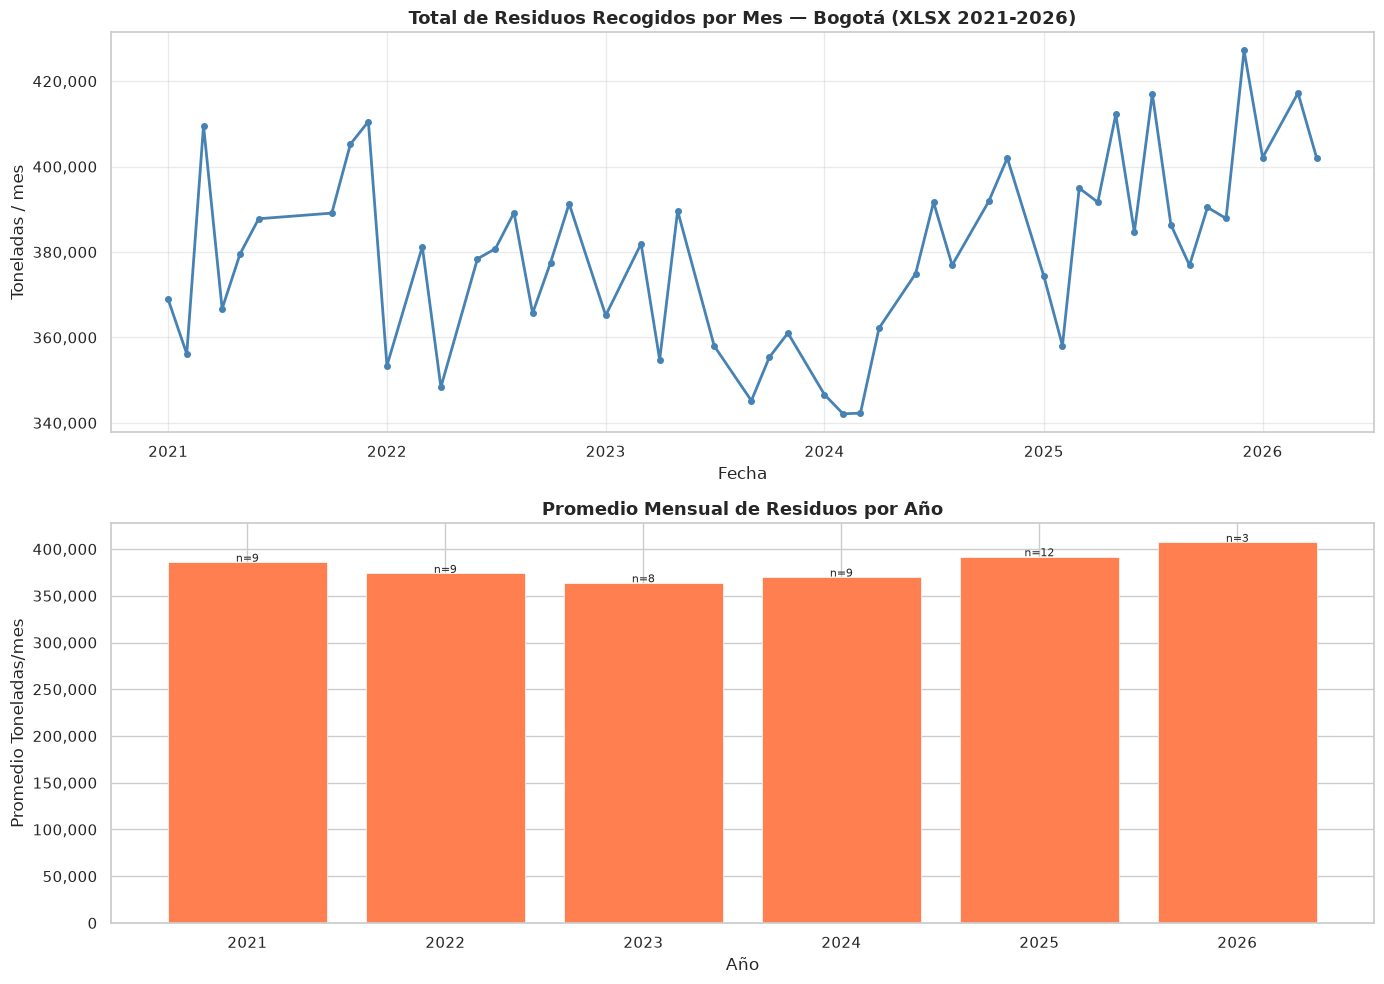

Gráfica guardada en outputs/01_serie_temporal_rbl.png


In [8]:
if not serie_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfica 1: Serie temporal de totales
    ax1 = axes[0]
    ax1.plot(serie_df['fecha'], serie_df['total_toneladas'],
             marker='o', linewidth=2, color='steelblue', markersize=4)
    ax1.set_title('Total de Residuos Recogidos por Mes — Bogotá (XLSX 2021-2026)',
                  fontsize=13, fontweight='bold')
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Toneladas / mes')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax1.grid(True, alpha=0.4)
    
    # Gráfica 2: Promedio anual
    ax2 = axes[1]
    anual = serie_df.groupby('año')['total_toneladas'].agg(['mean','count']).reset_index()
    bars = ax2.bar(anual['año'].astype(str), anual['mean'],
                   color='coral', edgecolor='white', linewidth=0.5)
    for bar, n in zip(bars, anual['count']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'n={n}', ha='center', fontsize=8)
    ax2.set_title('Promedio Mensual de Residuos por Año', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Año')
    ax2.set_ylabel('Promedio Toneladas/mes')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    plt.tight_layout()
    plt.savefig('../outputs/01_serie_temporal_rbl.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada en outputs/01_serie_temporal_rbl.png')
else:
    print('No hay datos para graficar — revisar lectura de XLSX')

## 6. Tabla de Decisiones — ¿Qué archivos pasan a Silver?

In [9]:
# Esta tabla se completa evaluando los resultados de las secciones anteriores
decisiones = []

for _, row in inv_df.iterrows():
    es_metadata = 'meta' in row['archivo'].lower() or 'metadata' in row['archivo'].lower()
    es_2015_2020_consolidado = '2015-2020' in row['archivo']
    
    if row['formato'] == '.xlsx':
        estado = '✅ USAR'
        razon = 'XLSX 2021-2026: esquema más uniforme, datos mensuales completos'
    elif es_metadata:
        estado = '⚠️ REFERENCIA'
        razon = 'Archivo de metadatos — no contiene datos de residuos'
    elif es_2015_2020_consolidado:
        estado = '✅ USAR'
        razon = 'CSV consolidado multi-año — validar columnas antes de incorporar'
    elif row['formato'] == '.csv' and row['tamaño_kb'] < 5:
        estado = '⚠️ EVALUAR'
        razon = 'CSV muy pequeño — posible metadata o datos incompletos. Revisar manualmente'
    elif row['formato'] == '.csv':
        estado = '⚠️ EVALUAR'
        razon = 'CSV 2017-2020: esquema variable entre años, requiere mapeo manual de columnas'
    else:
        estado = '❓ REVISAR'
        razon = 'Formato o contexto no identificado'
    
    decisiones.append({
        'año': row['año'],
        'archivo': row['archivo'],
        'formato': row['formato'],
        'tamaño_kb': row['tamaño_kb'],
        'decisión': estado,
        'razón': razon
    })

dec_df = pd.DataFrame(decisiones)

# Resumen
print('=== TABLA DE DECISIONES ===\n')
print(dec_df[['año','archivo','formato','decisión','razón']].to_string(index=False))
print('\n=== RESUMEN ===')
print(dec_df['decisión'].value_counts())

=== TABLA DE DECISIONES ===

 año                                                      archivo formato      decisión                                                                       razón
2017                              data_set_noviembre_2017_rbl.csv    .csv    ⚠️ EVALUAR CSV muy pequeño — posible metadata o datos incompletos. Revisar manualmente
2018                                 agosto-2018-rbl-residuos.csv    .csv    ⚠️ EVALUAR CSV muy pequeño — posible metadata o datos incompletos. Revisar manualmente
2018                                     data-set-agosto_2018.csv    .csv    ⚠️ EVALUAR CSV muy pequeño — posible metadata o datos incompletos. Revisar manualmente
2018                                data-set-rbl-febrero-2018.csv    .csv    ⚠️ EVALUAR CSV muy pequeño — posible metadata o datos incompletos. Revisar manualmente
2018                          data-set-rbl_nuevo_esquema_aseo.csv    .csv    ⚠️ EVALUAR CSV muy pequeño — posible metadata o datos incompletos. Revisar

In [10]:
# Guardar tabla de decisiones para referencia en script Silver
dec_df.to_csv('../Silver/decisiones_rbl.csv', index=False)
print('Tabla de decisiones guardada en Silver/decisiones_rbl.csv')
print('\n✅ NB-01 completado. Siguiente paso: ejecutar script 01_build_silver_rbl.py')

Tabla de decisiones guardada en Silver/decisiones_rbl.csv

✅ NB-01 completado. Siguiente paso: ejecutar script 01_build_silver_rbl.py
